In [1]:
# ----------------------------------------------------------
# IMPORT LIBRARIES
# ----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sns.set_style("whitegrid")

In [2]:
# ----------------------------------------------------------
# LOAD DATASET
# ----------------------------------------------------------

df = pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\Stock_Price.csv")


In [3]:
# ----------------------------------------------------------
# BASIC INFO
# ----------------------------------------------------------

df.head()

,mic,symbol,isin,date,open_value,high_value,low_value,last_value,change_prev_close_percentage,turnover
0,XZAG,CBX,HRZB00ICBEX6,2015-12-30,1689.22,1689.71,1673.62,1689.63,-0.02,2017520.82
1,XZAG,CBX,HRZB00ICBEX6,2015-12-29,1675.79,1691.02,1673.37,1689.94,0.84,1094356.06
2,XZAG,CBX,HRZB00ICBEX6,2015-12-28,1655.92,1677.17,1652.76,1675.88,1.21,1125687.29
3,XZAG,CBX,HRZB00ICBEX6,2015-12-23,1647.66,1655.77,1641.41,1655.77,0.49,592284.75
4,XZAG,CBX,HRZB00ICBEX6,2015-12-22,1655.71,1655.71,1642.60,1647.67,-0.55,2714509.05


In [4]:
df.shape

(1498, 10)

In [5]:
# ----------------------------------------------------------
# CHECK FOR NULL VALUES
# ----------------------------------------------------------

df.isnull().sum()


mic                             0
symbol                          0
isin                            0
date                            0
open_value                      1
high_value                      1
low_value                       1
last_value                      1
change_prev_close_percentage    1
turnover                        0
dtype: int64

In [6]:
# ----------------------------------------------------------
# HANDLE MISSING VALUES
# ----------------------------------------------------------
df[['open_value',
    'high_value',
    'low_value',
    'last_value',
    'change_prev_close_percentage']] = (
    df[['open_value',
        'high_value',
        'low_value',
        'last_value',
        'change_prev_close_percentage']]
    .interpolate(method='linear')
)

print("\nMissing Values After Treatment")
df.isnull().sum()


Missing Values After Treatment


mic                             0
symbol                          0
isin                            0
date                            0
open_value                      0
high_value                      0
low_value                       0
last_value                      0
change_prev_close_percentage    0
turnover                        0
dtype: int64

In [7]:
# ----------------------------------------------------------
# DATA PREPROCESSING
# ----------------------------------------------------------

df['date'] = pd.to_datetime(df['date'])

# Sort ascending for time series
df = df.sort_values('date')

# Set date as index
df.set_index('date', inplace=True)

print("\nDate Range:")
print(df.index.min(), "to", df.index.max())


Date Range:
2010-01-04 00:00:00 to 2015-12-30 00:00:00


In [8]:
# ----------------------------------------------------------
# SUMMARY STATISTICS
# ----------------------------------------------------------
df.describe()

,open_value,high_value,low_value,last_value,change_prev_close_percentage,turnover
count,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000,1.498000e+03
mean,1867.148872,1874.394299,1858.106806,1866.830638,-0.008865,1.492040e+06
std,170.752483,172.132654,169.273867,170.686472,0.715662,1.872377e+06
min,1619.750000,1622.370000,1612.690000,1619.350000,-4.660000,0.000000e+00
25%,1748.240000,1754.265000,1740.415000,1748.152500,-0.380000,7.234300e+05
50%,1809.895000,1816.060000,1801.120000,1809.600000,-0.020000,1.085926e+06
75%,1923.880000,1929.455000,1915.470000,1923.705000,0.370000,1.632190e+06
max,2334.960000,2338.310000,2323.920000,2333.760000,8.940000,3.058814e+07


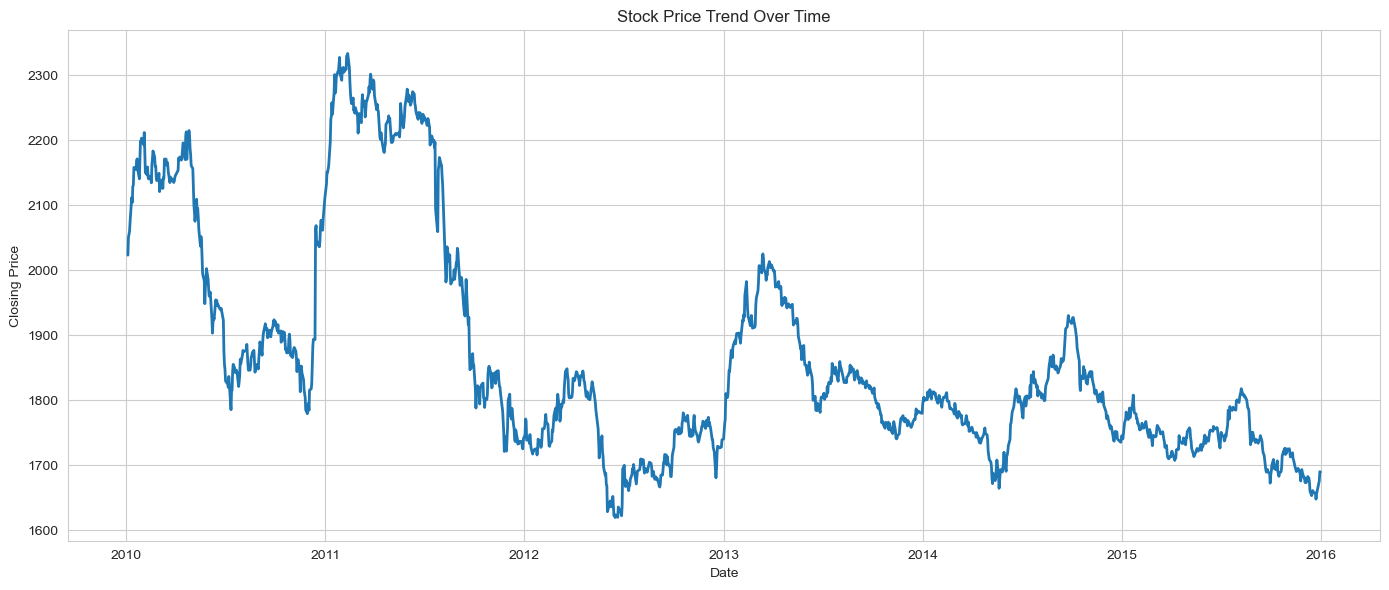

In [9]:
# ----------------------------------------------------------
# TREND ANALYSIS
# ----------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['last_value'],
    linewidth=2
)

plt.title("Stock Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\01_Stock_Price_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

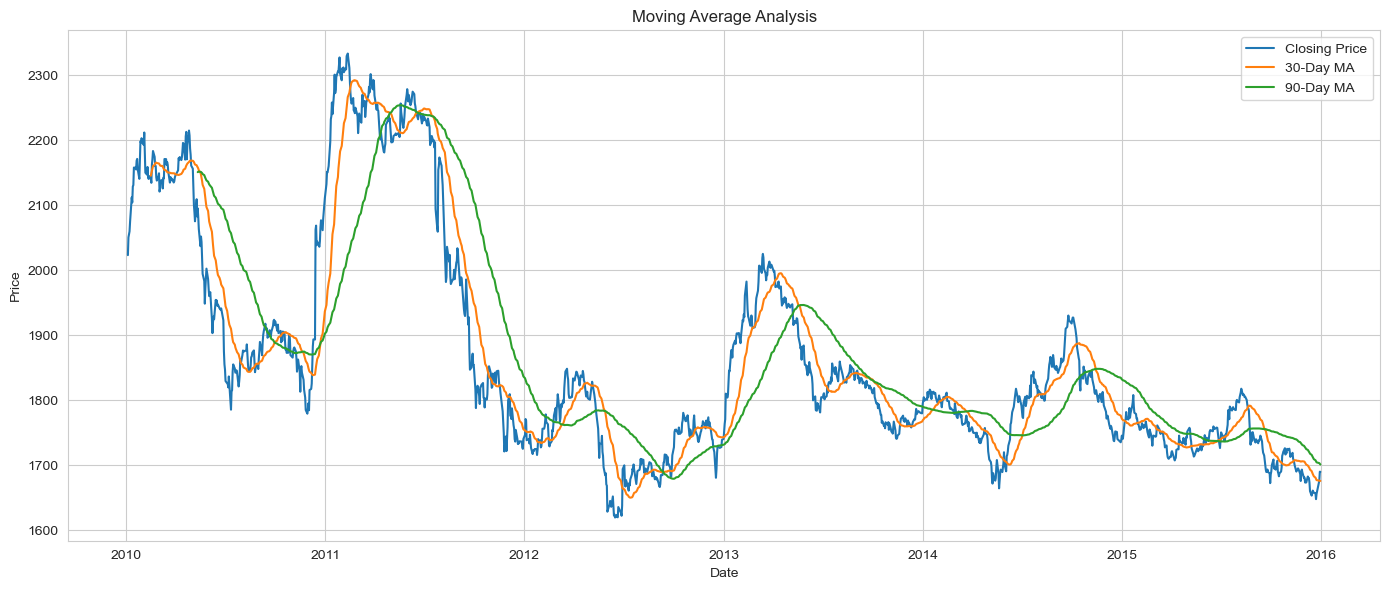

In [10]:
# ----------------------------------------------------------
# MOVING AVERAGES
# ----------------------------------------------------------

df['MA_30'] = df['last_value'].rolling(30).mean()
df['MA_90'] = df['last_value'].rolling(90).mean()

plt.figure(figsize=(14,6))

plt.plot(df['last_value'], label='Closing Price')
plt.plot(df['MA_30'], label='30-Day MA')
plt.plot(df['MA_90'], label='90-Day MA')

plt.title("Moving Average Analysis")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.tight_layout()

plt.savefig(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\02_Moving_Average_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

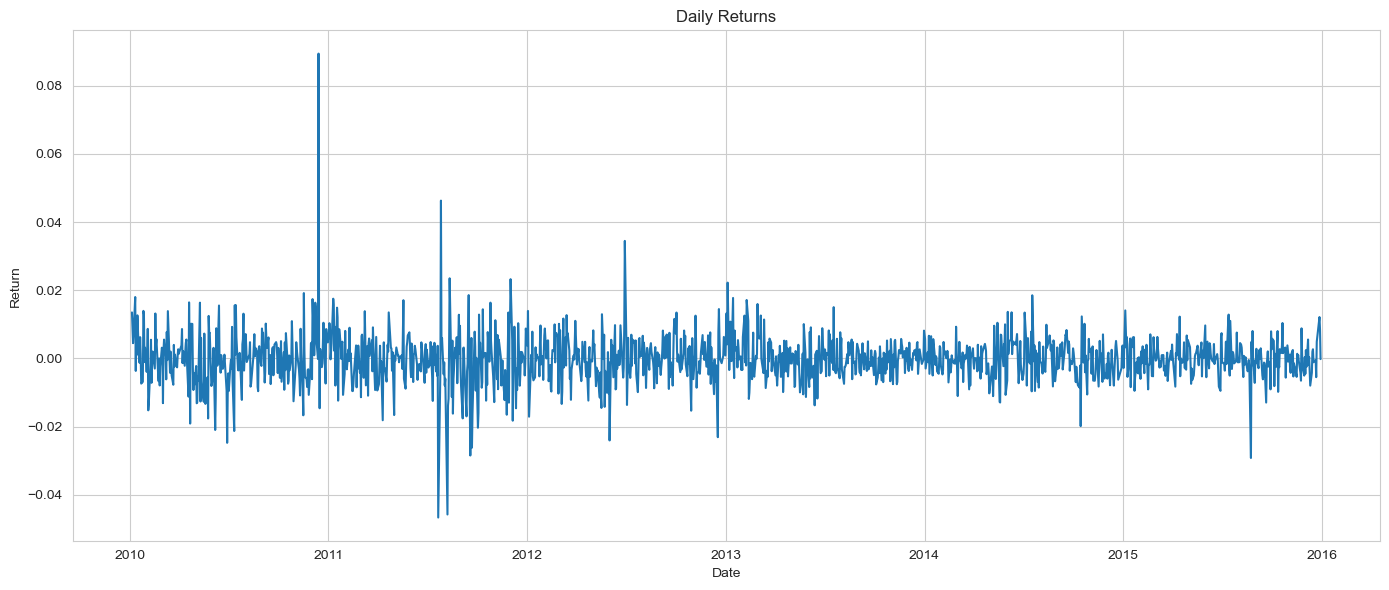

In [11]:
# ----------------------------------------------------------
# DAILY RETURNS
# ----------------------------------------------------------

df['daily_return'] = df['last_value'].pct_change()

plt.figure(figsize=(14,6))

plt.plot(df['daily_return'])

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\03_Daily_Returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

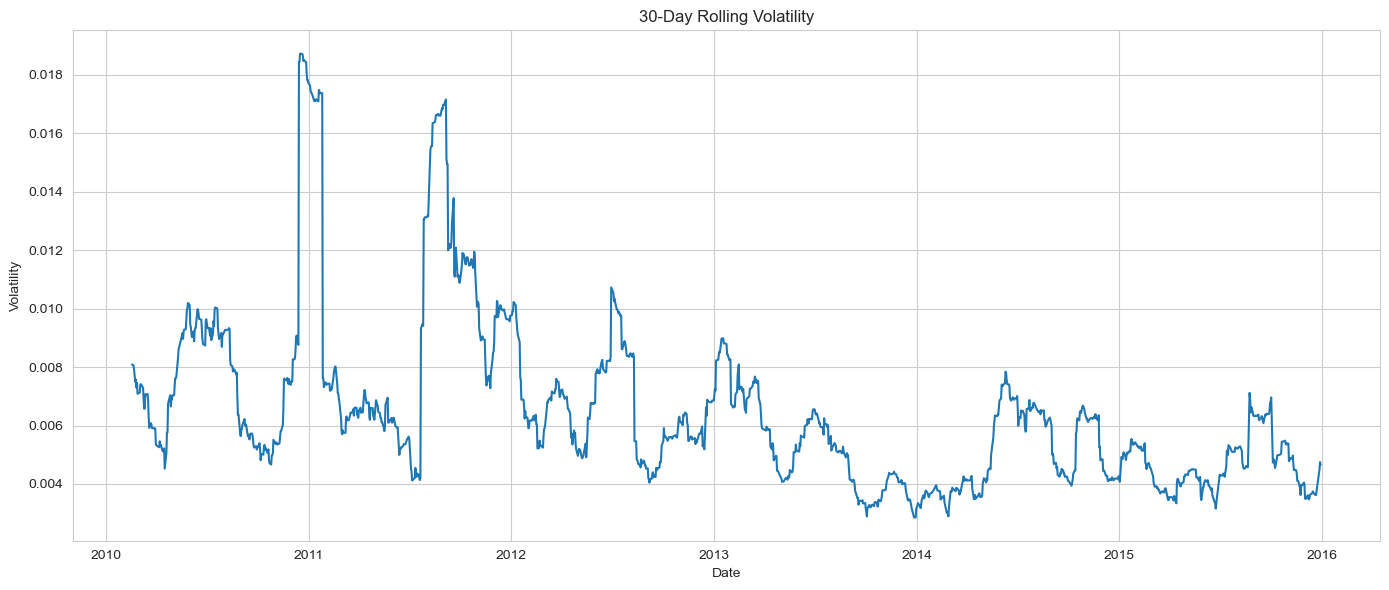

In [12]:
# ----------------------------------------------------------
# VOLATILITY ANALYSIS
# ----------------------------------------------------------

df['volatility'] = df['daily_return'].rolling(30).std()

plt.figure(figsize=(14,6))

plt.plot(df['volatility'])

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\04_Volatility_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_20396\4005714712.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_price = df['last_value'].resample('M').mean()


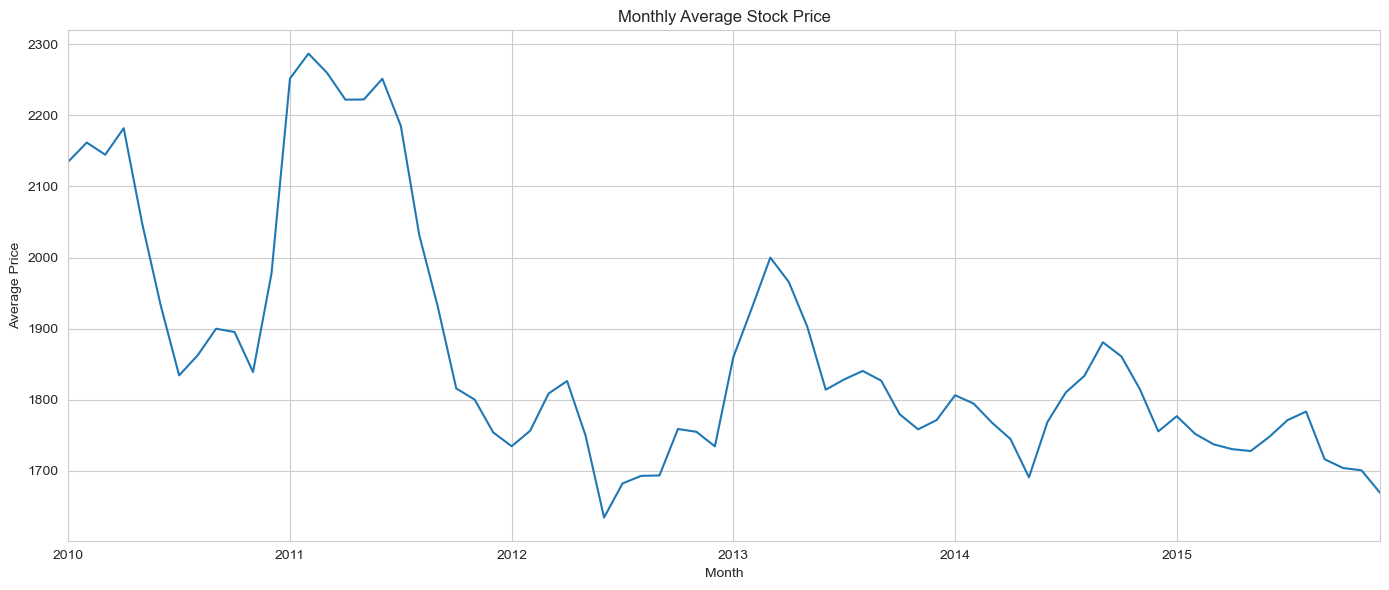

In [13]:
# ----------------------------------------------------------
# MONTHLY TREND
# ----------------------------------------------------------

monthly_price = df['last_value'].resample('M').mean()

plt.figure(figsize=(14,6))

monthly_price.plot()

plt.title("Monthly Average Stock Price")
plt.xlabel("Month")
plt.ylabel("Average Price")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\05_Monthly_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


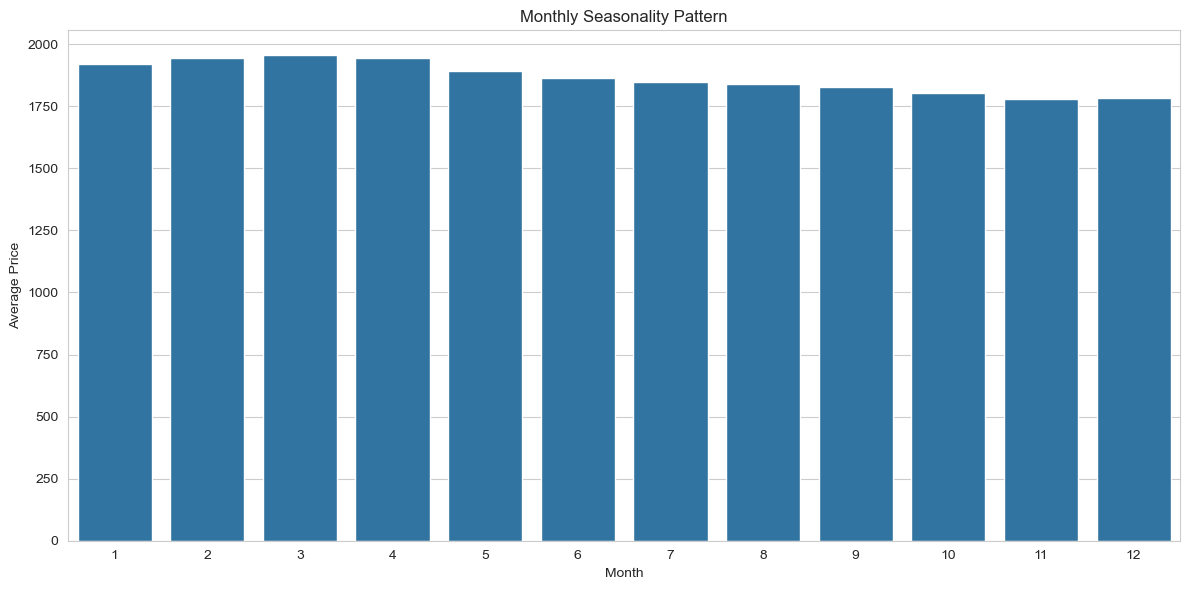

In [14]:
# ----------------------------------------------------------
# MONTHLY SEASONALITY
# ----------------------------------------------------------

df['Month'] = df.index.month

monthly_seasonality = (
    df.groupby('Month')['last_value']
      .mean()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=monthly_seasonality.index,
    y=monthly_seasonality.values
)

plt.title("Monthly Seasonality Pattern")
plt.xlabel("Month")
plt.ylabel("Average Price")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\06_Monthly_Seasonality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

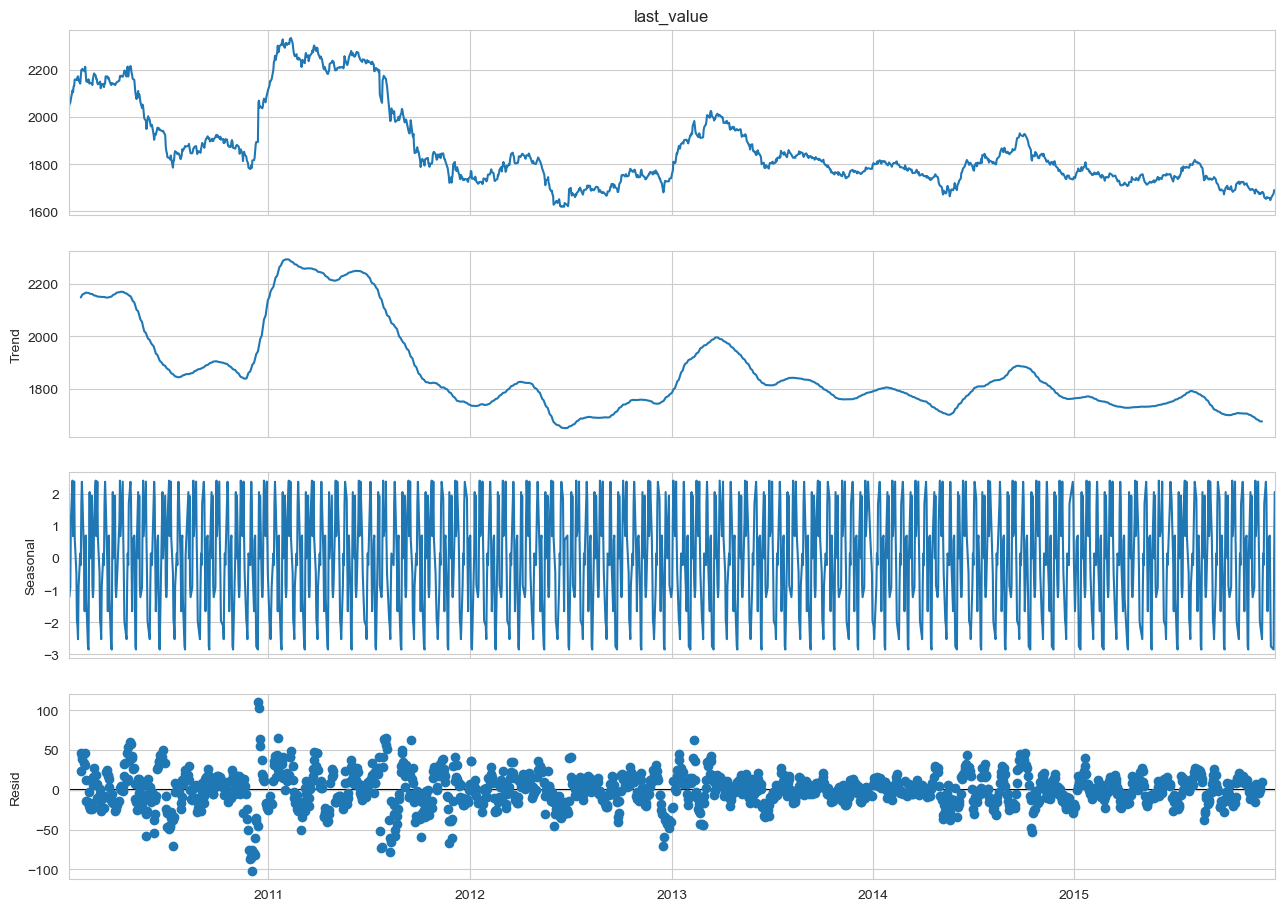

In [15]:
# ----------------------------------------------------------
# SEASONAL DECOMPOSITION
# ----------------------------------------------------------

seasonal_series = (
    df['last_value']
    .interpolate(method='linear')
    .dropna()
)

decomposition = seasonal_decompose(
    seasonal_series,
    model='additive',
    period=30
)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.savefig(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\07_Seasonal_Decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

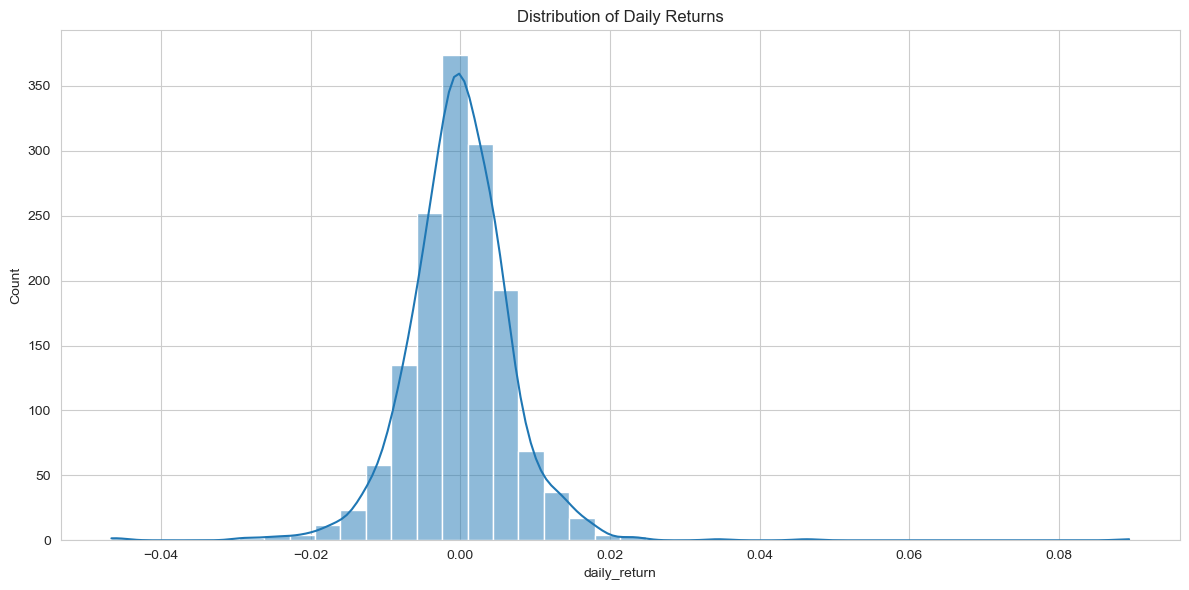

In [16]:
# ----------------------------------------------------------
# RETURN DISTRIBUTION
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

sns.histplot(
    df['daily_return'].dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\08_Return_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

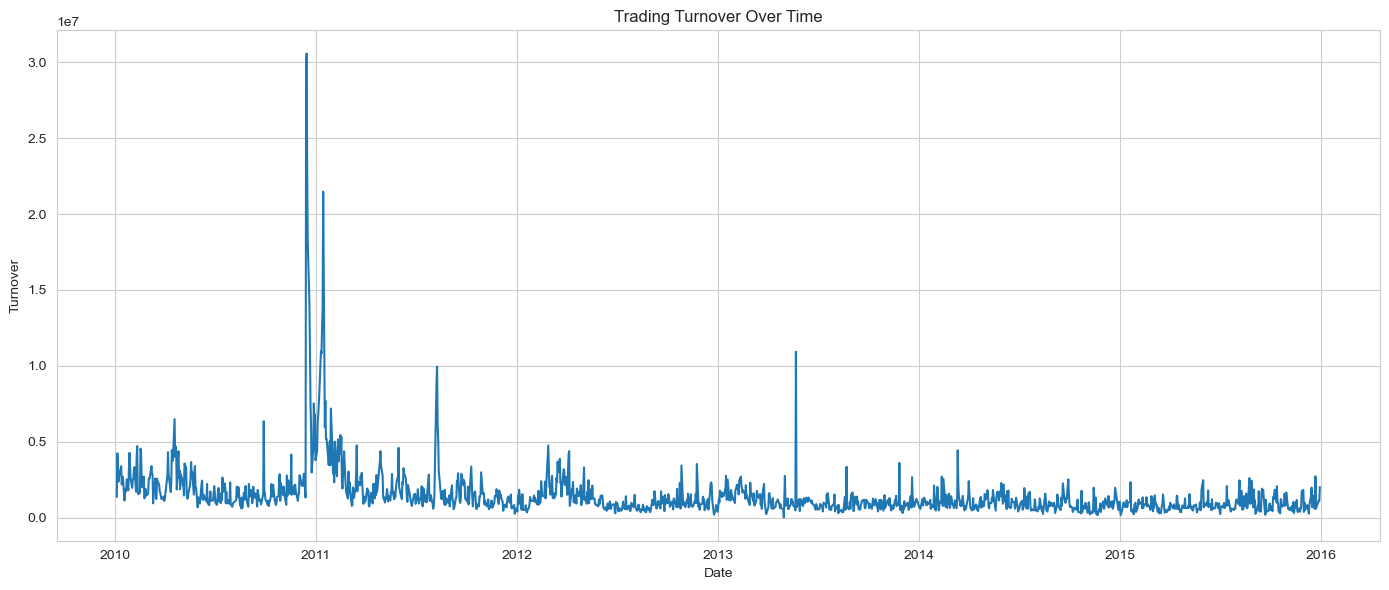

In [17]:
# ----------------------------------------------------------
# TURNOVER ANALYSIS
# ----------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(df['turnover'])

plt.title("Trading Turnover Over Time")
plt.xlabel("Date")
plt.ylabel("Turnover")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\09_Turnover_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

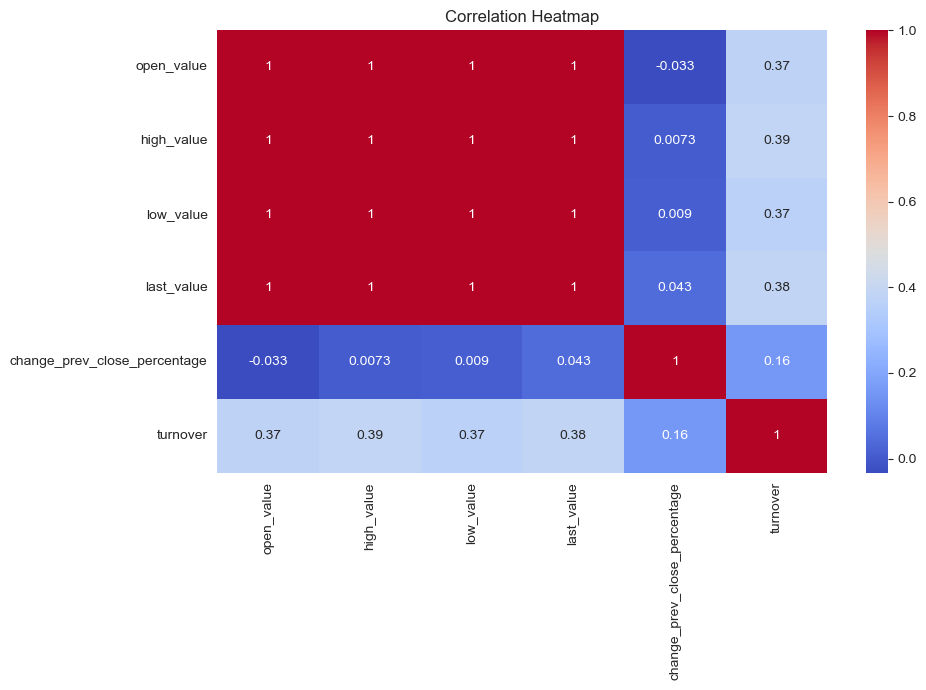

In [18]:
# ----------------------------------------------------------
# CORRELATION HEATMAP
# ----------------------------------------------------------

numerical_cols = [
    'open_value',
    'high_value',
    'low_value',
    'last_value',
    'change_prev_close_percentage',
    'turnover'
]

plt.figure(figsize=(10,7))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\10_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
# ----------------------------------------------------------
# FORECAST NEXT 30 DAYS
# ----------------------------------------------------------

model = ExponentialSmoothing(
    df['last_value'],
    trend='add',
    seasonal=None
)

fit = model.fit()

forecast_days = 30

forecast = fit.forecast(forecast_days)

plt.figure(figsize=(14,6))

plt.plot(
    df['last_value'].tail(250),
    label='Historical'
)

plt.plot(
    forecast,
    label='Forecast',
    linestyle='--'
)

plt.title("30-Day Future Forecast")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.tight_layout()

plt.savefig(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\11_Stock_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# ----------------------------------------------------------
# SAVE FORECAST VALUES
# ----------------------------------------------------------

forecast_df = pd.DataFrame({
    'Forecasted_Price': forecast
})

forecast_df.to_csv(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\Forecast_30_Days.csv"
)

In [ ]:
# ----------------------------------------------------------
# INSIGHTS
# ----------------------------------------------------------

print("\n")
print("="*70)
print("TIME SERIES ANALYSIS INSIGHTS")
print("="*70)

print(f"\nTotal Trading Days : {len(df)}")

print(f"\nHighest Stock Price : {df['last_value'].max():.2f}")

print(f"Lowest Stock Price : {df['last_value'].min():.2f}")

print(f"Average Stock Price : {df['last_value'].mean():.2f}")

print(f"\nAverage Daily Return : {df['daily_return'].mean()*100:.4f}%")

print(f"Average Volatility : {df['volatility'].mean()*100:.4f}%")

print(f"\nMaximum Turnover : {df['turnover'].max():,.2f}")

print(f"Average Turnover : {df['turnover'].mean():,.2f}")

if df['last_value'].iloc[-1] > df['MA_30'].iloc[-1]:
    trend = "UPWARD (Bullish)"
else:
    trend = "DOWNWARD (Bearish)"

print(f"\nCurrent Trend : {trend}")

print("\nForecast generated for next 30 trading periods.")

print("\nAnalysis Completed Successfully.")

In [ ]:
# ----------------------------------------------------------
# SAVE INSIGHTS
# ----------------------------------------------------------

with open(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task7\Time_Series_Insights.txt", "w") as f:

    f.write("TIME SERIES ANALYSIS INSIGHTS\n")
    f.write("="*50 + "\n")

    f.write(f"\nTotal Trading Days : {len(df)}")

    f.write(f"\nHighest Stock Price : {df['last_value'].max():.2f}")

    f.write(f"\nLowest Stock Price : {df['last_value'].min():.2f}")

    f.write(f"\nAverage Stock Price : {df['last_value'].mean():.2f}")

    f.write(f"\nAverage Daily Return : {df['daily_return'].mean()*100:.4f}%")

    f.write(f"\nAverage Volatility : {df['volatility'].mean()*100:.4f}%")

    f.write(f"\nMaximum Turnover : {df['turnover'].max():,.2f}")

    f.write(f"\nAverage Turnover : {df['turnover'].mean():,.2f}")

    f.write(f"\nCurrent Trend : {trend}")